In [1]:
!pip install byol-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [2]:
# ============================
# BYOL Training Pipeline for Fish Dataset
# ============================

import os
import random
import shutil
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18
from byol_pytorch import BYOL


In [3]:
# ============================
# 1️⃣ Set Paths
# ============================

root_dir = "/kaggle/input/fish-classification-dataset/Fish Data"
working_dir = "/kaggle/working/fish_dataset_split"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [4]:

# ============================
# 2️⃣ Prepare train/val/test Split
# ============================

if not os.path.exists(working_dir):
    os.makedirs(working_dir)

splits = ['train', 'val', 'test']
for s in splits:
    os.makedirs(os.path.join(working_dir, s), exist_ok=True)

# Go through each class
for cls in os.listdir(root_dir):
    class_dir = os.path.join(root_dir, cls)
    raw_folders = ['Raw', 'Raw Data']
    images = []

    for rf in raw_folders:
        path = os.path.join(class_dir, rf)
        if os.path.exists(path):
            images.extend(glob(os.path.join(path, "*")))

    random.shuffle(images)
    n = len(images)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    split_images = {
        'train': images[:n_train],
        'val': images[n_train:n_train+n_val],
        'test': images[n_train+n_val:]
    }

    for s in splits:
        dest_dir = os.path.join(working_dir, s, cls)
        os.makedirs(dest_dir, exist_ok=True)
        for img_path in split_images[s]:
            shutil.copy(img_path, dest_dir)

print("Dataset split into train/val/test successfully!")


Dataset split into train/val/test successfully!


In [5]:
# ============================
# 3️⃣ Define Transforms & Datasets
# ============================

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

train_dataset = ImageFolder(os.path.join(working_dir, 'train'), transform=train_transform)
val_dataset = ImageFolder(os.path.join(working_dir, 'val'), transform=test_transform)
test_dataset = ImageFolder(os.path.join(working_dir, 'test'), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


In [6]:
# ============================
# 4️⃣ Initialize BYOL
# ============================

device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = resnet18(pretrained=False)
backbone.fc = nn.Identity()  # remove classifier

byol_model = BYOL(
    backbone,
    image_size=224,
    hidden_layer='avgpool'
).to(device)

optimizer = optim.Adam(byol_model.parameters(), lr=1e-3)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [7]:
# ============================
# 5️⃣ BYOL Pre-training
# ============================

epochs = 100  # adjust as needed

for epoch in range(epochs):
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        loss = byol_model(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], BYOL Loss: {total_loss/len(train_loader):.4f}")

# Save backbone
torch.save(backbone.state_dict(), "byol_fish_backbone.pth")
print("BYOL pre-training finished and backbone saved!")


Epoch [1/100], BYOL Loss: 1.4704
Epoch [2/100], BYOL Loss: 1.4055
Epoch [3/100], BYOL Loss: 1.3925
Epoch [4/100], BYOL Loss: 1.3415
Epoch [5/100], BYOL Loss: 1.3277
Epoch [6/100], BYOL Loss: 1.2988
Epoch [7/100], BYOL Loss: 1.2874
Epoch [8/100], BYOL Loss: 1.2807
Epoch [9/100], BYOL Loss: 1.2952
Epoch [10/100], BYOL Loss: 1.2464
Epoch [11/100], BYOL Loss: 1.2671
Epoch [12/100], BYOL Loss: 1.2397
Epoch [13/100], BYOL Loss: 1.2336
Epoch [14/100], BYOL Loss: 1.2135
Epoch [15/100], BYOL Loss: 1.1941
Epoch [16/100], BYOL Loss: 1.2231
Epoch [17/100], BYOL Loss: 1.2023
Epoch [18/100], BYOL Loss: 1.2049
Epoch [19/100], BYOL Loss: 1.1695
Epoch [20/100], BYOL Loss: 1.1620
Epoch [21/100], BYOL Loss: 1.1912
Epoch [22/100], BYOL Loss: 1.1757
Epoch [23/100], BYOL Loss: 1.1713
Epoch [24/100], BYOL Loss: 1.1708
Epoch [25/100], BYOL Loss: 1.1877
Epoch [26/100], BYOL Loss: 1.1902
Epoch [27/100], BYOL Loss: 1.1473
Epoch [28/100], BYOL Loss: 1.1404
Epoch [29/100], BYOL Loss: 1.1532
Epoch [30/100], BYOL Lo

In [8]:
# ============================
# 6️⃣ Fine-tune Classifier (Improved)
# ============================

from torch.optim.lr_scheduler import StepLR

# Use lighter transforms for classifier training
classifier_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

# Reload datasets with lighter transforms
train_dataset = ImageFolder(os.path.join(working_dir, 'train'), transform=classifier_transform)
val_dataset = ImageFolder(os.path.join(working_dir, 'val'), transform=classifier_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

# Unfreeze last ResNet block for fine-tuning
for name, param in backbone.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

num_classes = len(train_dataset.classes)
classifier = nn.Linear(512, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(
    list(classifier.parameters()) + 
    [p for n, p in backbone.named_parameters() if p.requires_grad], 
    lr=1e-4
)

scheduler = StepLR(optimizer_cls, step_size=10, gamma=0.5)  # reduce LR every 10 epochs

epochs_cls = 50  # increase epochs

best_val_acc = 0.0
best_model = None

for epoch in range(epochs_cls):
    classifier.train()
    backbone.train()  # unfreeze last block
    total_loss = 0
    total_correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs_cls}], Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")

    # Validation
    classifier.eval()
    backbone.eval()
    total_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            features = backbone(images)
            outputs = classifier(features)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = total_correct / len(val_dataset)
    print(f"Validation Acc: {val_acc:.4f}")

    # Save best model based on val accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = {
            'backbone': backbone.state_dict(),
            'classifier': classifier.state_dict()
        }

    scheduler.step()

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

# ============================
# 7️⃣ Evaluate on Test Set
# ============================

test_dataset = ImageFolder(os.path.join(working_dir, 'test'), transform=classifier_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

backbone.load_state_dict(best_model['backbone'])
classifier.load_state_dict(best_model['classifier'])
backbone.eval()
classifier.eval()

total_correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)
        total_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = total_correct / len(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch [1/50], Loss: 2.4787, Train Acc: 0.2645
Validation Acc: 0.4427
Epoch [2/50], Loss: 1.6102, Train Acc: 0.5285
Validation Acc: 0.6363
Epoch [3/50], Loss: 1.1123, Train Acc: 0.6633
Validation Acc: 0.7360
Epoch [4/50], Loss: 0.8448, Train Acc: 0.7425
Validation Acc: 0.7841
Epoch [5/50], Loss: 0.6626, Train Acc: 0.7980
Validation Acc: 0.8123
Epoch [6/50], Loss: 0.5366, Train Acc: 0.8405
Validation Acc: 0.8406
Epoch [7/50], Loss: 0.4452, Train Acc: 0.8673
Validation Acc: 0.8904
Epoch [8/50], Loss: 0.3815, Train Acc: 0.8847
Validation Acc: 0.9056
Epoch [9/50], Loss: 0.3283, Train Acc: 0.9041
Validation Acc: 0.9261
Epoch [10/50], Loss: 0.2814, Train Acc: 0.9203
Validation Acc: 0.9239
Epoch [11/50], Loss: 0.2434, Train Acc: 0.9307
Validation Acc: 0.9417
Epoch [12/50], Loss: 0.2262, Train Acc: 0.9346
Validation Acc: 0.9450
Epoch [13/50], Loss: 0.2122, Train Acc: 0.9390
Validation Acc: 0.9440
Epoch [14/50], Loss: 0.2005, Train Acc: 0.9437
Validation Acc: 0.9499
Epoch [15/50], Loss: 0.1895, 

In [9]:
# ============================
# 7️⃣ Evaluate on Test Set
# ============================

classifier.eval()
total_correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)
        total_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = total_correct / len(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9734


<Figure size 1200x1200 with 0 Axes>

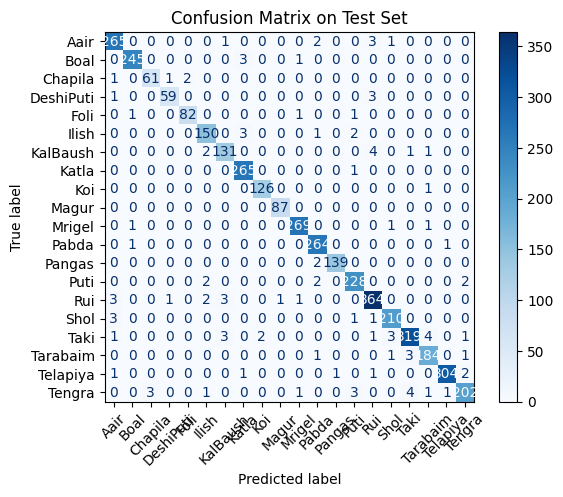

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

# Make sure model is in eval mode
backbone.eval()
classifier.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=test_dataset.classes)

# Plot
plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()


In [11]:
from sklearn.metrics import roc_auc_score
import torch
import numpy as np
from sklearn.preprocessing import label_binarize

# Ensure model is in eval mode
backbone.eval()
classifier.eval()

all_outputs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)
        probs = torch.softmax(outputs, dim=1)
        all_outputs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Concatenate all batches
all_outputs = np.concatenate(all_outputs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# One-hot encode labels
num_classes = len(test_dataset.classes)
all_labels_onehot = label_binarize(all_labels, classes=np.arange(num_classes))

# Compute ROC-AUC per class
roc_auc_per_class = roc_auc_score(all_labels_onehot, all_outputs, average=None)

for i, cls in enumerate(test_dataset.classes):
    print(f"Class {cls} ROC-AUC: {roc_auc_per_class[i]:.4f}")

# Optional: macro-average ROC-AUC
roc_auc_macro = roc_auc_score(all_labels_onehot, all_outputs, average='macro')
print(f"Macro-average ROC-AUC: {roc_auc_macro:.4f}")


Class Aair ROC-AUC: 0.9998
Class Boal ROC-AUC: 1.0000
Class Chapila ROC-AUC: 0.9999
Class DeshiPuti ROC-AUC: 0.9998
Class Foli ROC-AUC: 1.0000
Class Ilish ROC-AUC: 0.9998
Class KalBaush ROC-AUC: 0.9992
Class Katla ROC-AUC: 1.0000
Class Koi ROC-AUC: 1.0000
Class Magur ROC-AUC: 1.0000
Class Mrigel ROC-AUC: 0.9995
Class Pabda ROC-AUC: 1.0000
Class Pangas ROC-AUC: 1.0000
Class Puti ROC-AUC: 0.9998
Class Rui ROC-AUC: 0.9995
Class Shol ROC-AUC: 0.9998
Class Taki ROC-AUC: 0.9995
Class Tarabaim ROC-AUC: 0.9997
Class Telapiya ROC-AUC: 1.0000
Class Tengra ROC-AUC: 0.9985
Macro-average ROC-AUC: 0.9997


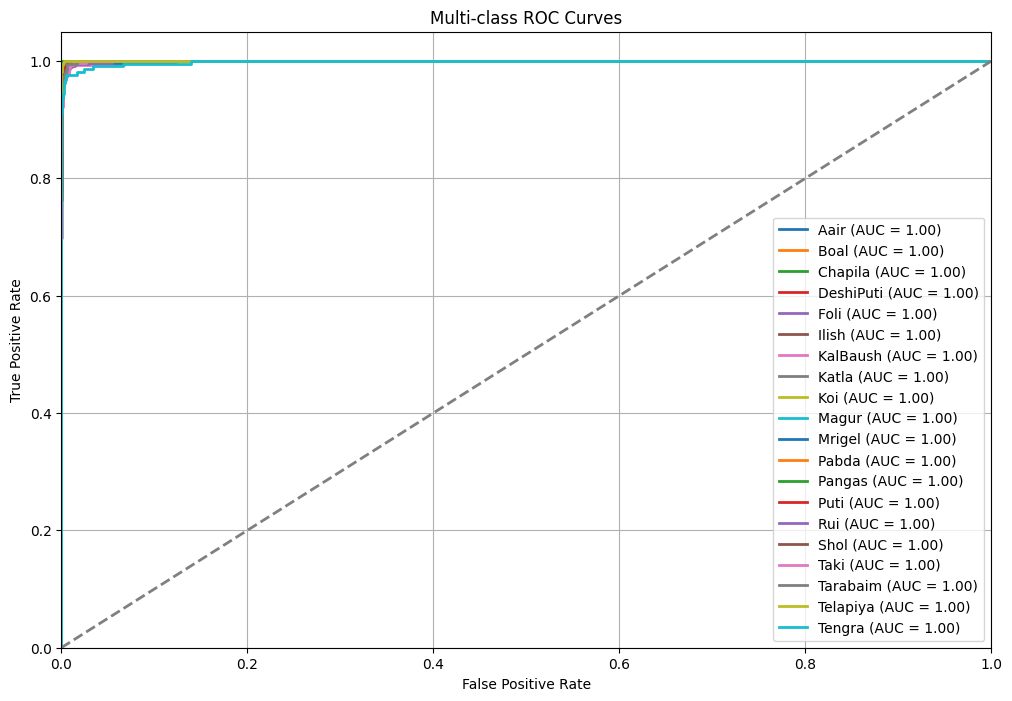

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, cls in enumerate(test_dataset.classes):
    fpr, tpr, _ = roc_curve(all_labels_onehot[:, i], all_outputs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


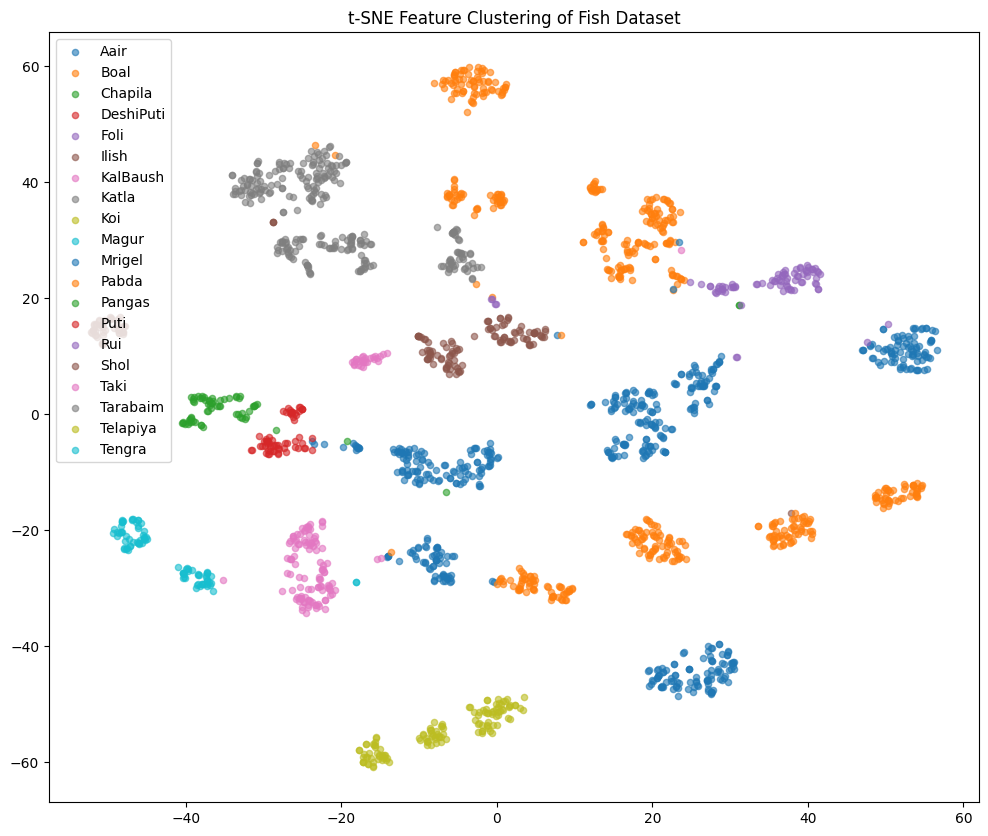

In [13]:
# ==================================
# 🔎 t-SNE Feature Clustering
# ==================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne(backbone, dataloader, class_names, n_samples=2000):
    backbone.eval()
    feats, labels = [], []
    device = next(backbone.parameters()).device

    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            f = backbone(images).cpu().numpy()
            feats.append(f)
            labels.extend(lbls.numpy())

            if len(labels) >= n_samples:
                break

    feats = np.concatenate(feats, axis=0)
    labels = np.array(labels)

    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    feats_2d = tsne.fit_transform(feats)

    # Plot
    plt.figure(figsize=(12, 10))
    for i, cls in enumerate(class_names):
        idxs = labels == i
        plt.scatter(
            feats_2d[idxs, 0],
            feats_2d[idxs, 1],
            label=cls,
            alpha=0.6,
            s=20
        )
    plt.legend()
    plt.title("t-SNE Feature Clustering of Fish Dataset")
    plt.show()

# ✅ Run t-SNE on test set features
plot_tsne(backbone, test_loader, test_dataset.classes, n_samples=2000)
